In [1]:
import torch
from torch.utils.data import DataLoader, random_split, TensorDataset
from d2l import torch as d2l
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt
import numpy as np
import time
import random

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MTFraEng(d2l.DataModule):
    def _download(self):
        d2l.extract(d2l.download(
            d2l.DATA_URL + 'fra-eng.zip', self.root,
            '94646ad1522d915e7b0f9296181140edcf86a4f5'))
        with open(self.root + '/fra-eng/fra.txt', encoding='utf-8') as f:
            return f.read()

raw_text = MTFraEng()._download()

def tokenize_simple(text):
    return text.lower().strip().split()

def custom_preprocess(text):
    lines = text.strip().split('\n')
    pairs = [line.split('\t') for line in lines if '\t' in line]
    src = [tokenize_simple(s) for s, _ in pairs]
    tgt = [tokenize_simple(t) for _, t in pairs]
    return src, tgt

src_sentences, tgt_sentences = custom_preprocess(raw_text)
src_sentences = src_sentences[:3000]
tgt_sentences = tgt_sentences[:3000]

reserved_tokens = ['<pad>', '<bos>', '<eos>', '<unk>']
src_vocab = d2l.Vocab(src_sentences, min_freq=1, reserved_tokens=reserved_tokens)
tgt_vocab = d2l.Vocab(tgt_sentences, min_freq=1, reserved_tokens=reserved_tokens)

pad_idx = tgt_vocab['<pad>']
bos_idx = tgt_vocab['<bos>']
eos_idx = tgt_vocab['<eos>']

def build_tensor(lines, vocab, num_steps, bos=False, eos=False):
    out = []
    for line in lines:
        tokens = ([vocab['<bos>']] if bos else []) + \
                 [vocab[token] if token in vocab.token_to_idx else vocab['<unk>'] for token in line] + \
                 ([vocab['<eos>']] if eos else [])
        if len(tokens) > num_steps:
            tokens = tokens[:num_steps]
        else:
            tokens += [vocab['<pad>']] * (num_steps - len(tokens))
        out.append(torch.tensor(tokens))
    return torch.stack(out)

num_steps = 20
src_tensor = build_tensor(src_sentences, src_vocab, num_steps, eos=True)
tgt_tensor = build_tensor(tgt_sentences, tgt_vocab, num_steps, bos=True, eos=True)


full_dataset = TensorDataset(src_tensor, tgt_tensor)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

test_pairs = list(zip(
    [" ".join(s) for s in src_sentences[:10]],
    [" ".join(t) for t in tgt_sentences[:10]]
))

def batch_predict(model, src_sentences, src_vocab, tgt_vocab, max_len=20):
    model.eval()
    predictions = []

    with torch.no_grad():
        for sentence in src_sentences:
            tokens = sentence.lower().strip().split()
            token_ids = [src_vocab[token] if token in src_vocab.token_to_idx else src_vocab['<unk>'] for token in tokens]
            token_ids.append(src_vocab['<eos>'])

            src_tensor = torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(1)
            encoder_outputs, hidden = model.encoder(src_tensor)

            input_token = torch.tensor([bos_idx], device=device)
            output_tokens = []

            for _ in range(max_len):
                output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs)
                top1 = output.argmax(1)
                if top1.item() == eos_idx:
                    break
                output_tokens.append(tgt_vocab.idx_to_token[top1.item()])
                input_token = top1

            predictions.append(" ".join(output_tokens))
    
    return predictions

def tokenizer_src(sentence):
    tokens = sentence.lower().strip().split()
    token_ids = [src_vocab[token] if token in src_vocab.token_to_idx else src_vocab['<unk>'] for token in tokens]
    token_ids.append(src_vocab['<eos>'])
    return torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(1)

In [3]:
class MultiHeadAttention(d2l.Module):
    def __init__(self, num_hiddens, num_heads, dropout, bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.attention = d2l.DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=bias)

    def split_heads(self, X):
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(-1, X.shape[2], X.shape[3])

    def merge_heads(self, X):
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
        X = X.permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], X.shape[1], -1)

    def forward(self, queries, keys, values, valid_lens):
        queries = self.split_heads(self.W_q(queries))
        keys = self.split_heads(self.W_k(keys))
        values = self.split_heads(self.W_v(values))
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)
        output = self.attention(queries, keys, values, valid_lens)
        return self.W_o(self.merge_heads(output)), output 

class MultiHeadAttentiveDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, encoder_hidden_size, decoder_hidden_size, num_heads, n_layers=1, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.attention = MultiHeadAttention(embed_size, num_heads, dropout)
        self.rnn = nn.GRU(embed_size * 2, decoder_hidden_size, num_layers=n_layers, dropout=dropout if n_layers > 1 else 0)
        self.fc = nn.Linear(decoder_hidden_size, vocab_size)

    def forward(self, input_token, hidden_state, encoder_outputs, valid_lens=None):
        embedded = self.embedding(input_token).unsqueeze(0)
        decoder_hidden = hidden_state[-1].unsqueeze(1)
        context, attn_weights = self.attention(decoder_hidden, encoder_outputs, encoder_outputs, valid_lens)
        rnn_input = torch.cat((embedded, context.permute(1, 0, 2)), dim=2) 
        output, hidden = self.rnn(rnn_input, hidden_state)
        output = self.fc(output.squeeze(0))
    
        return output, hidden, attn_weights

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, n_layers=1, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, num_layers=n_layers, dropout=dropout if n_layers > 1 else 0)

    def forward(self, input_seq):
        embedded = self.embedding(input_seq)
        outputs, hidden = self.rnn(embedded)
        return outputs.transpose(0, 1), hidden

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        tgt_len, batch_size = tgt.shape
        vocab_size = self.decoder.fc.out_features
        outputs = torch.zeros(tgt_len, batch_size, vocab_size).to(src.device)
        attentions = []
        encoder_outputs, hidden = self.encoder(src)
        input_token = tgt[0, :]
        for t in range(1, tgt_len):
            output, hidden, attn_weights = self.decoder(input_token, hidden, encoder_outputs)
            outputs[t, :, :] = output
            attentions.append(attn_weights)
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = tgt[t] if teacher_force else output.argmax(1)
    
        return outputs, attentions



In [4]:
def training_multihead(model, train_loader, val_loader, optimizer, criterion, num_epochs, teacher_forcing_ratio=0.5):
    train_losses, val_losses = [], []
    for epoch in range(num_epochs):
        model.train()
        total_loss, total_tokens = 0, 0

        for src, tgt in train_loader:
            src, tgt = src.to(device), tgt.to(device)
            optimizer.zero_grad()
            output, _ = model(src.T, tgt.T, teacher_forcing_ratio=teacher_forcing_ratio)
            loss = criterion(output[1:].reshape(-1, output.shape[-1]), tgt.T[1:].reshape(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * tgt.T[1:].numel()
            total_tokens += tgt.T[1:].numel()

        avg_train_loss = total_loss / total_tokens
        train_losses.append(avg_train_loss)

        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f} | Perplexity: {np.exp(avg_train_loss):.2f}")

        if val_loader:
            model.eval()
            val_loss, val_tokens = 0, 0
            with torch.no_grad():
                for src, tgt in val_loader:
                    src, tgt = src.to(device), tgt.to(device)
                    output, _ = model(src.T, tgt.T, teacher_forcing_ratio=0)
                    loss = criterion(output[1:].reshape(-1, output.shape[-1]), tgt.T[1:].reshape(-1))
                    val_loss += loss.item() * tgt.T[1:].numel()
                    val_tokens += tgt.T[1:].numel()
            avg_val_loss = val_loss / val_tokens
            val_losses.append(avg_val_loss)
            print(f"Epoch {epoch+1} - Val Loss: {avg_val_loss:.4f} | Val Perplexity: {np.exp(avg_val_loss):.2f}")

    return train_losses, val_losses

def predict(model, src_tensor, max_len=20, start_token=1):
    if src_tensor.dim() == 1:
        src_tensor = src_tensor.unsqueeze(1)

    model.eval()
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        input_token = torch.tensor([start_token], device=src_tensor.device)
        outputs = []
        attentions = []

        for _ in range(max_len):
            output, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)
            predicted = output.argmax(1)
            outputs.append(predicted.item())
            if attn_weights is not None:
                attentions.append(attn_weights.squeeze(2).squeeze(0).detach().cpu())
            if predicted.item() == eos_idx:
                break
            input_token = predicted

        if attentions:
            stacked_attentions = torch.stack(attentions)
        else:
            stacked_attentions = None

        return outputs, stacked_attentions

def evaluate_bleu(model, test_pairs, tgt_vocab):
    model.eval()
    total_score = 0
    for src_text, tgt_text in test_pairs:
        src_tensor = tokenizer_src(src_text)
        pred_indices, _ = predict(model, src_tensor)
        score = compute_bleu(pred_indices, tgt_text, tgt_vocab)
        total_score += score
    return total_score / len(test_pairs)

def compute_bleu(pred_indices, tgt_sentence, tgt_vocab):
    pred_tokens = [tgt_vocab.idx_to_token[idx] for idx in pred_indices if idx < len(tgt_vocab)]
    ref_tokens = tgt_sentence.lower().split()
    smoothing = SmoothingFunction().method1
    return sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoothing)


 Multi-Head Config 1: 1 heads
Epoch 1 - Train Loss: 4.6141 | Perplexity: 100.90
Epoch 1 - Val Loss: 4.4480 | Val Perplexity: 85.46
Epoch 2 - Train Loss: 3.5409 | Perplexity: 34.50
Epoch 2 - Val Loss: 4.2068 | Val Perplexity: 67.14
Epoch 3 - Train Loss: 2.8945 | Perplexity: 18.07
Epoch 3 - Val Loss: 4.1634 | Val Perplexity: 64.29
Epoch 4 - Train Loss: 2.3619 | Perplexity: 10.61
Epoch 4 - Val Loss: 4.0557 | Val Perplexity: 57.73
Epoch 5 - Train Loss: 1.9299 | Perplexity: 6.89
Epoch 5 - Val Loss: 4.1204 | Val Perplexity: 61.58
Epoch 6 - Train Loss: 1.5933 | Perplexity: 4.92
Epoch 6 - Val Loss: 4.1086 | Val Perplexity: 60.86
Epoch 7 - Train Loss: 1.2766 | Perplexity: 3.58
Epoch 7 - Val Loss: 4.2134 | Val Perplexity: 67.58
Epoch 8 - Train Loss: 1.0711 | Perplexity: 2.92
Epoch 8 - Val Loss: 4.2217 | Val Perplexity: 68.15
Epoch 9 - Train Loss: 0.8813 | Perplexity: 2.41
Epoch 9 - Val Loss: 4.3180 | Val Perplexity: 75.04
Epoch 10 - Train Loss: 0.7953 | Perplexity: 2.22
Epoch 10 - Val Loss: 4.4

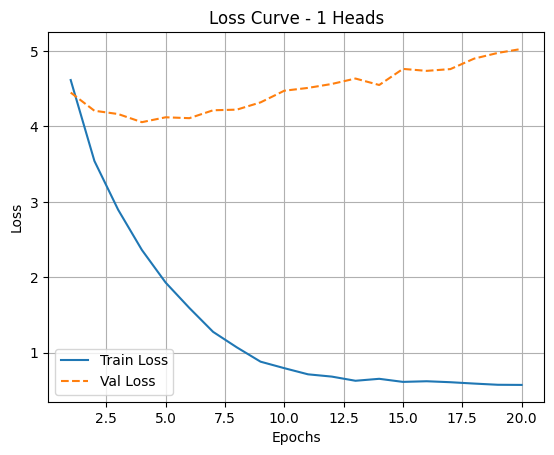

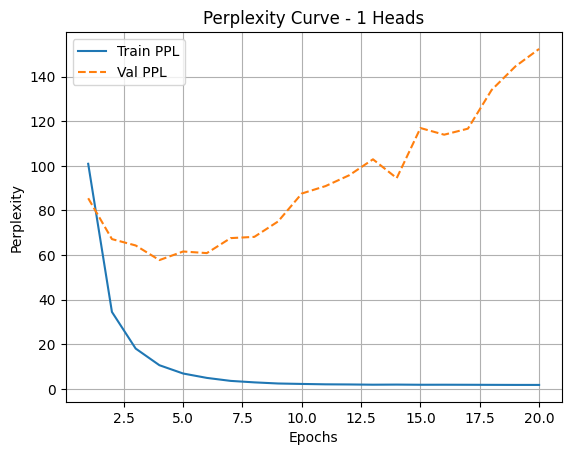


 Sample Predictions (1 heads):

Source: go.
Predicted: va ! <eos>
Target: va !

Source: hi.
Predicted: salut ! <eos>
Target: salut !

Source: run!
Predicted: ça. <eos>
Target: cours !

Source: run!
Predicted: ça. <eos>
Target: courez !

Source: who?
Predicted: ? <eos>
Target: qui ?

Source: wow!
Predicted: ça ! <eos>
Target: ça alors !

Source: fire!
Predicted: joue ! <eos>
Target: au feu !

Source: help!
Predicted: à l'aide ! <eos>
Target: à l'aide !

Source: jump.
Predicted: saute. <eos>
Target: saute.

Source: stop!
Predicted: ça suffit ! <eos>
Target: ça suffit !


 Multi-Head Config 2: 2 heads
Epoch 1 - Train Loss: 4.6118 | Perplexity: 100.66
Epoch 1 - Val Loss: 4.3154 | Val Perplexity: 74.85
Epoch 2 - Train Loss: 3.5068 | Perplexity: 33.34
Epoch 2 - Val Loss: 4.1608 | Val Perplexity: 64.12
Epoch 3 - Train Loss: 2.7907 | Perplexity: 16.29
Epoch 3 - Val Loss: 4.0186 | Val Perplexity: 55.62
Epoch 4 - Train Loss: 2.2657 | Perplexity: 9.64
Epoch 4 - Val Loss: 4.0276 | Val Perplexity:

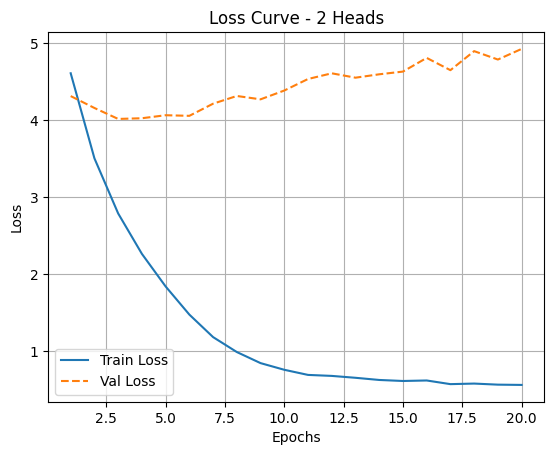

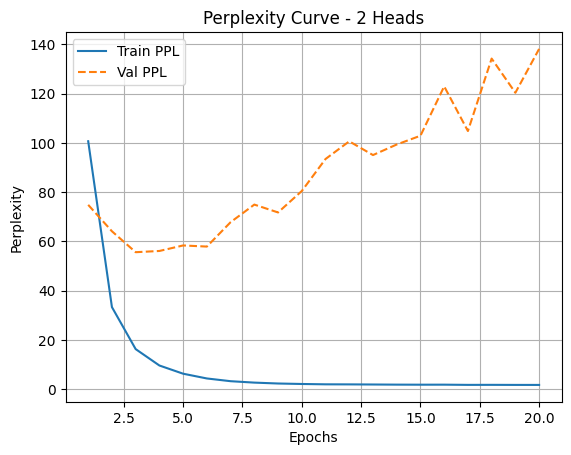


 Sample Predictions (2 heads):

Source: go.
Predicted: ! <eos>
Target: va !

Source: hi.
Predicted: salut ! <eos>
Target: salut !

Source: run!
Predicted: ! <eos>
Target: cours !

Source: run!
Predicted: ! <eos>
Target: courez !

Source: who?
Predicted: qui ? <eos>
Target: qui ?

Source: wow!
Predicted: ans. <eos>
Target: ça alors !

Source: fire!
Predicted: ! <eos>
Target: au feu !

Source: help!
Predicted: l'aide <eos>
Target: à l'aide !

Source: jump.
Predicted: saute. <eos>
Target: saute.

Source: stop!
Predicted: ans. <eos>
Target: ça suffit !


 Multi-Head Config 3: 4 heads
Epoch 1 - Train Loss: 4.5322 | Perplexity: 92.96
Epoch 1 - Val Loss: 4.2939 | Val Perplexity: 73.25
Epoch 2 - Train Loss: 3.5006 | Perplexity: 33.13
Epoch 2 - Val Loss: 4.2500 | Val Perplexity: 70.11
Epoch 3 - Train Loss: 2.9028 | Perplexity: 18.22
Epoch 3 - Val Loss: 4.2205 | Val Perplexity: 68.06
Epoch 4 - Train Loss: 2.4032 | Perplexity: 11.06
Epoch 4 - Val Loss: 4.0415 | Val Perplexity: 56.91
Epoch 5 - Tr

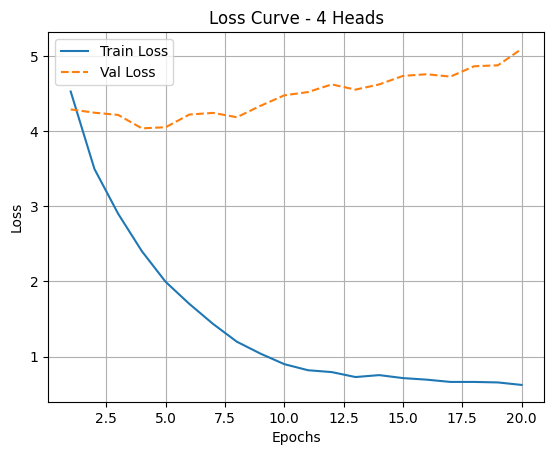

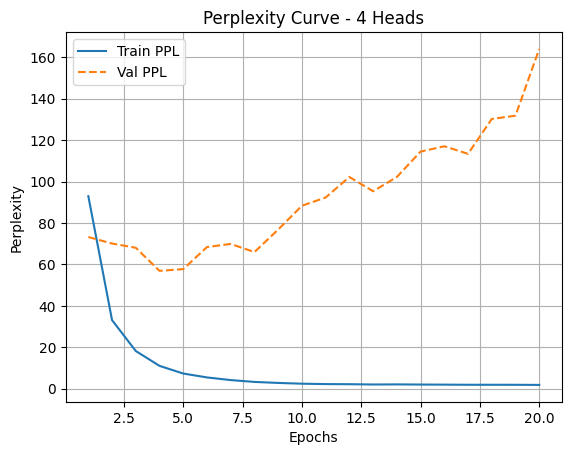


 Sample Predictions (4 heads):

Source: go.
Predicted: va ! <eos>
Target: va !

Source: hi.
Predicted: salut ! <eos>
Target: salut !

Source: run!
Predicted: courez ! <eos>
Target: cours !

Source: run!
Predicted: courez ! <eos>
Target: courez !

Source: who?
Predicted: ? <eos>
Target: qui ?

Source: wow!
Predicted: ça ! <eos>
Target: ça alors !

Source: fire!
Predicted: restez ! <eos>
Target: au feu !

Source: help!
Predicted: à l'aide ! <eos>
Target: à l'aide !

Source: jump.
Predicted: saute. <eos>
Target: saute.

Source: stop!
Predicted: ça suffit ! <eos>
Target: ça suffit !


 Multi-Head Config 4: 8 heads
Epoch 1 - Train Loss: 4.5693 | Perplexity: 96.48
Epoch 1 - Val Loss: 4.3329 | Val Perplexity: 76.16
Epoch 2 - Train Loss: 3.4382 | Perplexity: 31.13
Epoch 2 - Val Loss: 4.1454 | Val Perplexity: 63.14
Epoch 3 - Train Loss: 2.7790 | Perplexity: 16.10
Epoch 3 - Val Loss: 4.0707 | Val Perplexity: 58.60
Epoch 4 - Train Loss: 2.2685 | Perplexity: 9.66
Epoch 4 - Val Loss: 4.0218 | Val 

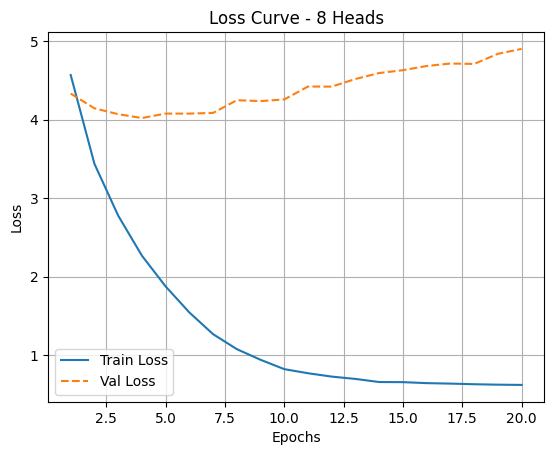

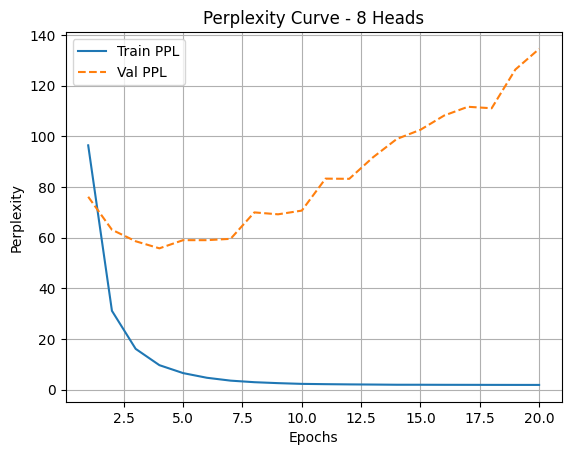


 Sample Predictions (8 heads):

Source: go.
Predicted: y ! <eos>
Target: va !

Source: hi.
Predicted: salut ! <eos>
Target: salut !

Source: run!
Predicted: cours ! <eos>
Target: cours !

Source: run!
Predicted: cours ! <eos>
Target: courez !

Source: who?
Predicted: ? <eos>
Target: qui ?

Source: wow!
Predicted: ça ! <eos>
Target: ça alors !

Source: fire!
Predicted: à l'abri ! <eos>
Target: au feu !

Source: help!
Predicted: à l'aide ! <eos>
Target: à l'aide !

Source: jump.
Predicted: saute. <eos>
Target: saute.

Source: stop!
Predicted: suffit ! <eos>
Target: ça suffit !



In [5]:
base_hyperparams = {
    "emb_dim": 128,
    "hid_dim": 256,
    "n_layers": 1,
    "dropout": 0.1,
    "lr": 0.001,
    "num_epochs": 20,
    "batch_size": 4
}

head_configs = [1, 2, 4, 8]
results = []

for i, num_heads in enumerate(head_configs):
    print(f"\n Multi-Head Config {i+1}: {num_heads} heads")

    encoder = Encoder(len(src_vocab),
                      base_hyperparams["emb_dim"],
                      base_hyperparams["hid_dim"],
                      n_layers=base_hyperparams["n_layers"],
                      dropout=base_hyperparams["dropout"])
    
    decoder = MultiHeadAttentiveDecoder(len(tgt_vocab), base_hyperparams["emb_dim"],
                                        base_hyperparams["hid_dim"], 
                                        base_hyperparams["hid_dim"],
                                        num_heads=num_heads,
                                        n_layers=base_hyperparams["n_layers"],
                                        dropout=base_hyperparams["dropout"])
    
    model = Seq2SeqWithAttention(encoder, decoder).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=base_hyperparams["lr"])
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    train_losses, val_losses = training_multihead(model, train_loader, val_loader, optimizer, criterion, num_epochs=base_hyperparams["num_epochs"],teacher_forcing_ratio=0.7)
    bleu_score = evaluate_bleu(model, test_pairs, tgt_vocab)
    print(f"\n BLEU Score ({num_heads} heads): {bleu_score:.4f}")

#plot loss
    epochs = list(range(1, len(train_losses) + 1))
    plt.figure()
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, linestyle="--", label="Val Loss")
    plt.title(f"Loss Curve - {num_heads} Heads")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

#plot perplexity
    train_ppl = [np.exp(l) for l in train_losses]
    val_ppl = [np.exp(l) for l in val_losses]
    plt.figure()
    plt.plot(epochs, train_ppl, label="Train PPL")
    plt.plot(epochs, val_ppl, linestyle="--", label="Val PPL")
    plt.title(f"Perplexity Curve - {num_heads} Heads")
    plt.xlabel("Epochs")
    plt.ylabel("Perplexity")
    plt.legend()
    plt.grid()
    plt.show()

    print(f"\n Sample Predictions ({num_heads} heads):\n")
    for src_text, tgt_text in test_pairs:
        src_tensor = tokenizer_src(src_text)
        pred_indices, _ = predict(model, src_tensor)
        pred_tokens = [tgt_vocab.idx_to_token[idx] for idx in pred_indices if idx < len(tgt_vocab)]
        print(f"Source: {src_text}")
        print(f"Predicted: {' '.join(pred_tokens)}")
        print(f"Target: {tgt_text}\n")

    results.append({
        "num_heads": num_heads,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "bleu": bleu_score
    })



 Example 1
Source: go.
Target: va !
Predicted: y ! <eos>
Attention weights shape: torch.Size([3, 8, 1, 16])


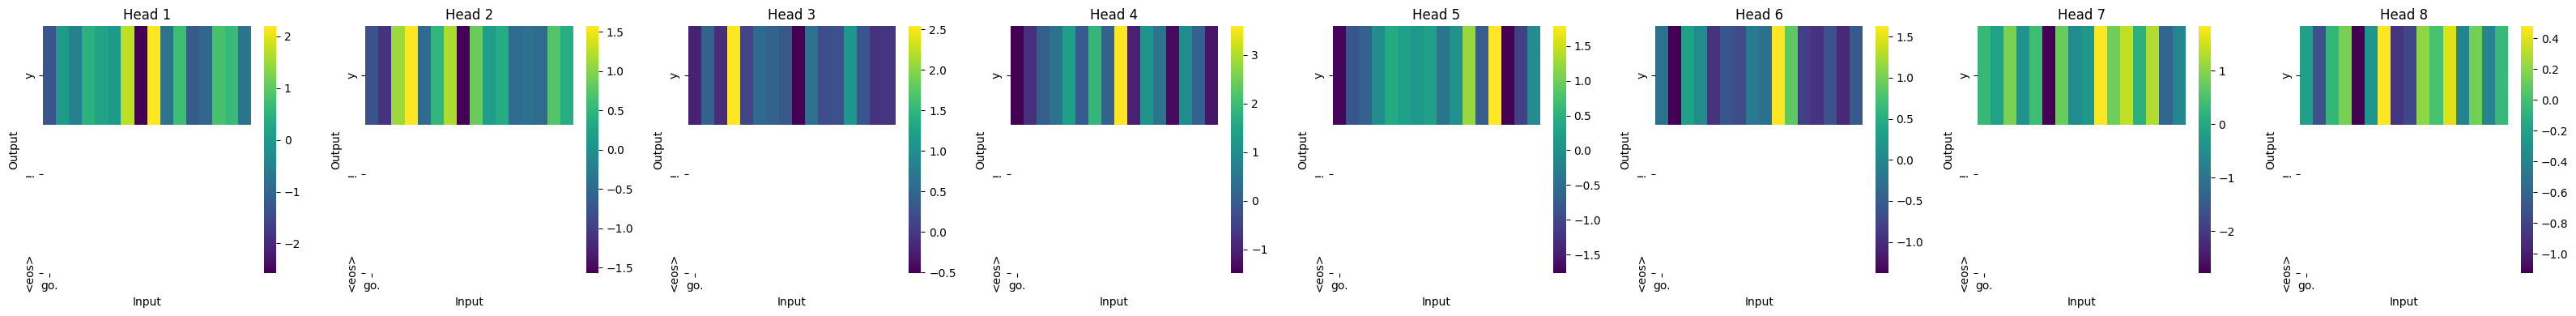


 Example 2
Source: hi.
Target: salut !
Predicted: salut ! <eos>
Attention weights shape: torch.Size([3, 8, 1, 16])


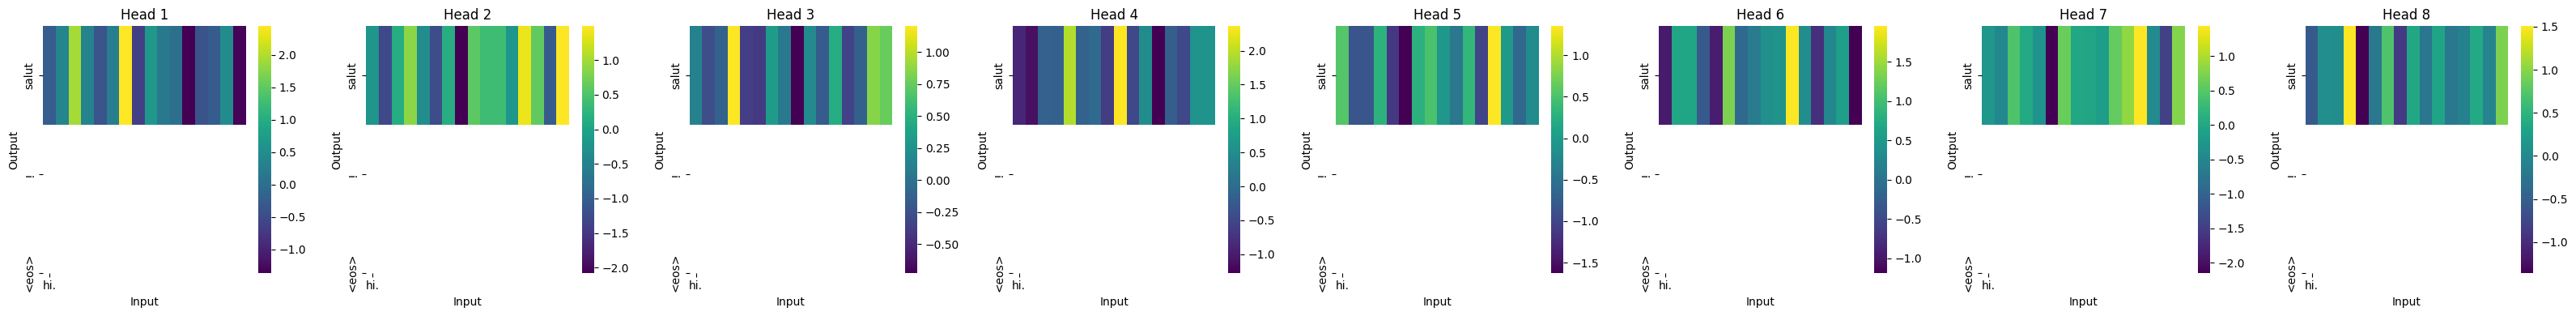


 Example 3
Source: run!
Target: cours !
Predicted: cours ! <eos>
Attention weights shape: torch.Size([3, 8, 1, 16])


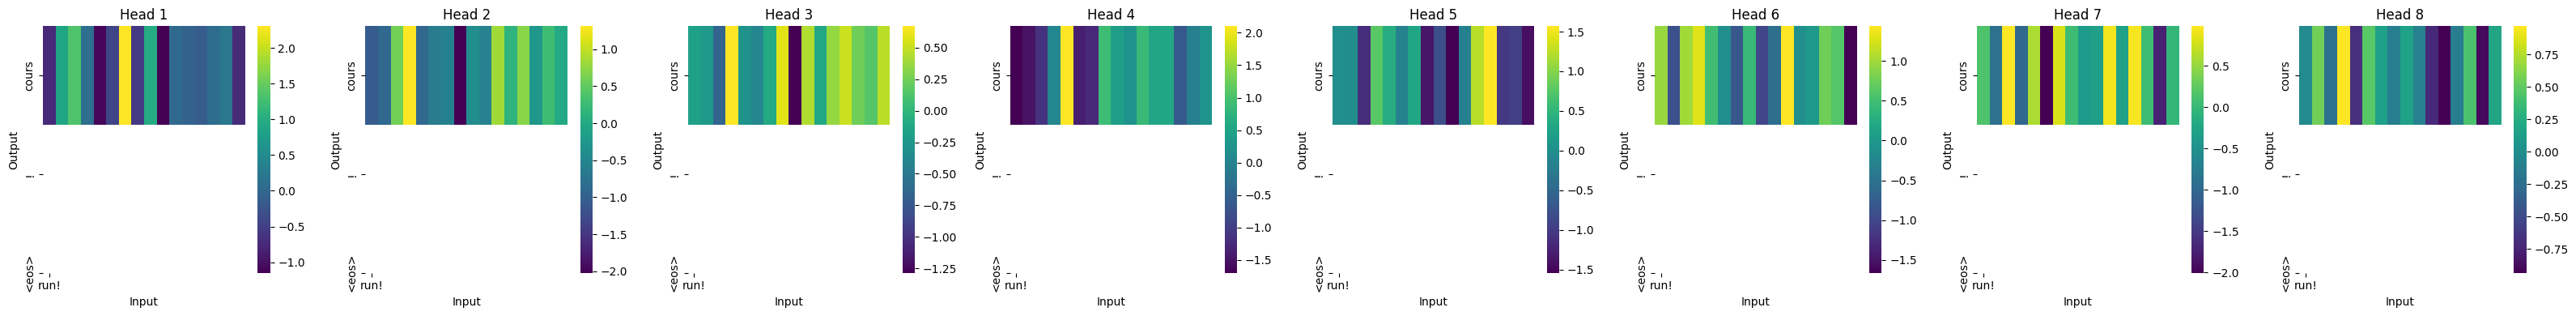


 Example 4
Source: run!
Target: courez !
Predicted: cours ! <eos>
Attention weights shape: torch.Size([3, 8, 1, 16])


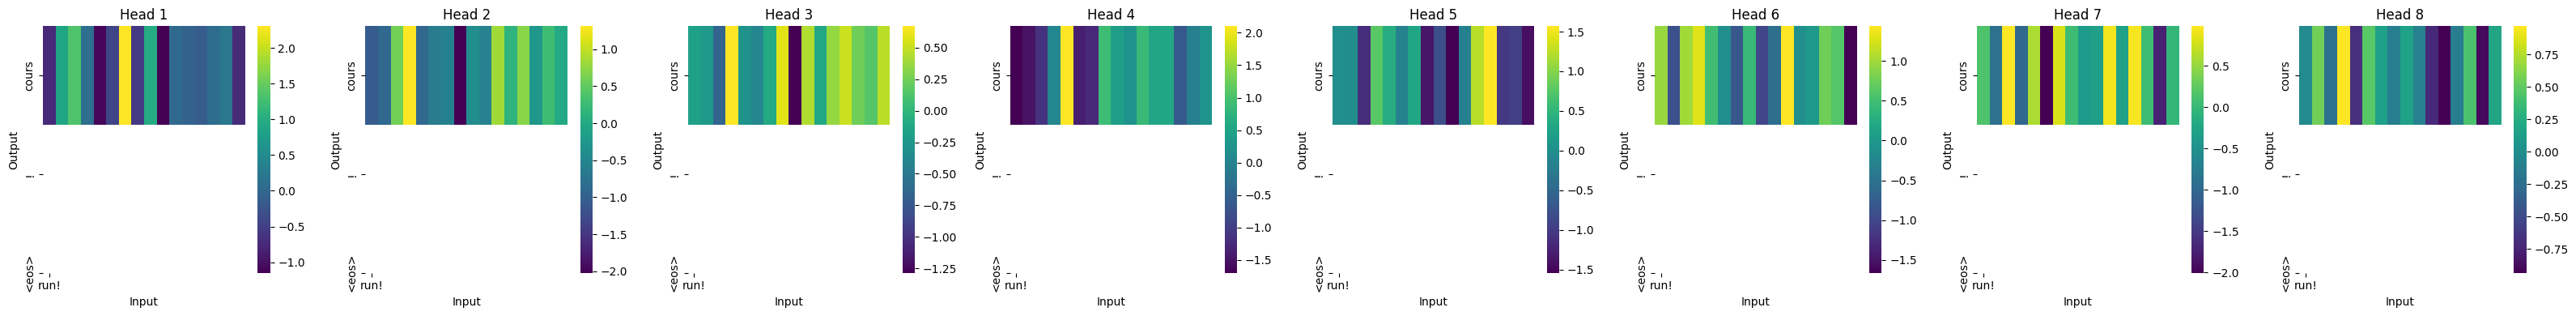


 Example 5
Source: who?
Target: qui ?
Predicted: ? <eos>
Attention weights shape: torch.Size([2, 8, 1, 16])


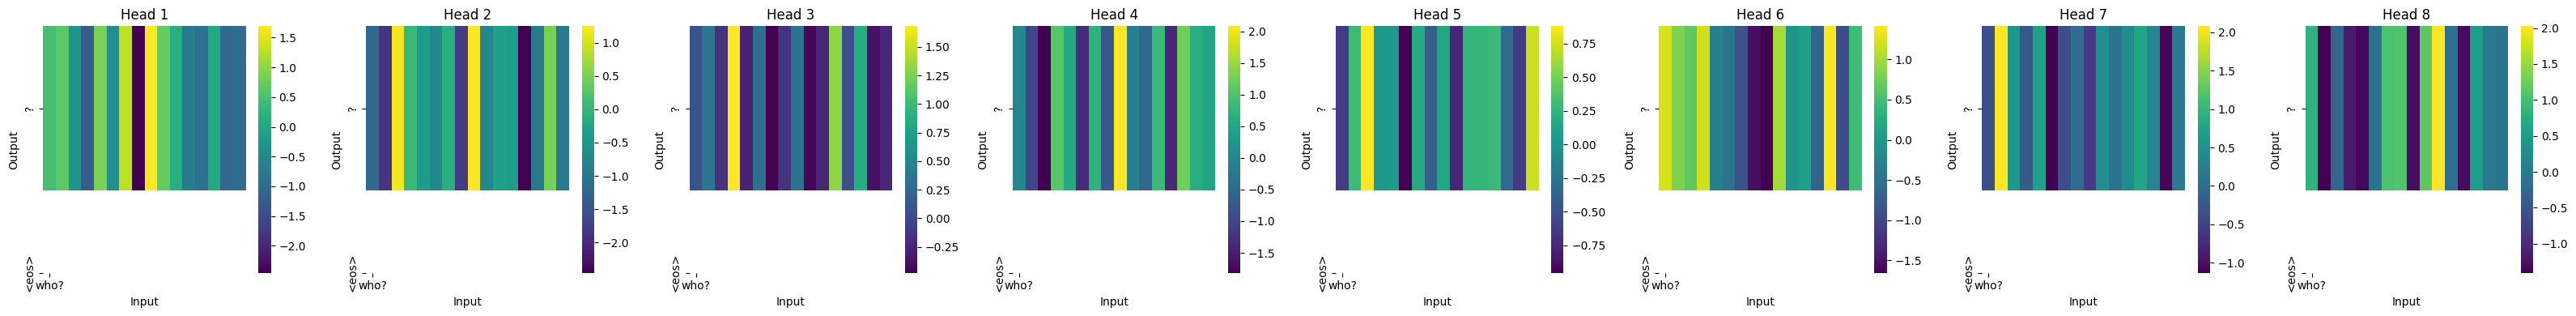

In [9]:
import seaborn as sns

def plot_multihead_attention(attn_weights, input_tokens, output_tokens):
    if attn_weights.dim() == 4:
        attn_weights = attn_weights[0]
    if attn_weights.dim() != 3:
        raise ValueError(f"Expected 3D tensor (num_heads, tgt_len, src_len), got shape {attn_weights.shape}")
    num_heads, tgt_len, src_len = attn_weights.shape
    fig, axes = plt.subplots(1, num_heads, figsize=(4 * num_heads, 4))
    if num_heads == 1:
        axes = [axes]
    for head in range(num_heads):
        sns.heatmap(attn_weights[head].detach().cpu().numpy(),
                    xticklabels=input_tokens, 
                    yticklabels=output_tokens,
                    cmap='viridis',
                    ax=axes[head])
        axes[head].set_title(f"Head {head + 1}")
        axes[head].set_xlabel("Input")
        axes[head].set_ylabel("Output")

    plt.tight_layout()
    plt.show()

visual_examples = test_pairs[:5]
for i, (src_text, tgt_text) in enumerate(visual_examples):
    print(f"\n Example {i+1}")
    print(f"Source: {src_text}")
    print(f"Target: {tgt_text}")
    src_tensor = tokenizer_src(src_text)
    pred_indices, attn_weights = predict(model, src_tensor)
    input_tokens = src_text.lower().split()
    output_tokens = [tgt_vocab.idx_to_token[idx] for idx in pred_indices]
    print(f"Predicted: {' '.join(output_tokens)}")
    print(f"Attention weights shape: {attn_weights.shape}")

    plot_multihead_attention(attn_weights, input_tokens, output_tokens)